In [13]:
# LIBRARY
import os
import shutil
import random
import warnings

import librosa
import soundfile as sf
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPool2D,
    Flatten,
    Dense,
    Dropout
)

warnings.filterwarnings("ignore")

In [ ]:
# INITIAL FOLDERING

BASE_DIR = "Dataset"

RAW_DIR = os.path.join(BASE_DIR, "part-rusak")
PRE_DIR = os.path.join(BASE_DIR, "preprocessed")
SPLIT_DIR = os.path.join(BASE_DIR, "split")
AUG_DIR = os.path.join(BASE_DIR, "augmented")
FEATURE_DIR = os.path.join(BASE_DIR, "features")

SR = 16000

classes = [
    "Clutch-Shoe",
    "Conecting-Rod",
    "Drive-Belt",
    "Piston",
    "Tensioner",
    "Slider",
    "Roller"
]

os.makedirs(PRE_DIR, exist_ok=True)
os.makedirs(FEATURE_DIR, exist_ok=True)

In [3]:
# PREPROCESING

def preprocess_audio(path):

    y, _ = librosa.load(
        path,
        sr=SR,
        mono=True
    )

    y, _ = librosa.effects.trim(
        y,
        top_db=30
    )

    peak = np.max(np.abs(y))

    if peak > 0:
        y = y / peak

    return y.astype(np.float32)



for cls in classes:

    in_dir = os.path.join(RAW_DIR, cls)

    if not os.path.exists(in_dir):
        continue

    out_dir = os.path.join(PRE_DIR, cls)

    os.makedirs(out_dir, exist_ok=True)

    files = [
        f for f in os.listdir(in_dir)
        if f.endswith((".wav", ".mp3", ".m4a"))
    ]

    for f in files:

        y = preprocess_audio(
            os.path.join(in_dir, f)
        )

        sf.write(
            os.path.join(
                out_dir,
                f"{os.path.splitext(f)[0]}.wav"
            ),
            y,
            SR
        )

print("Preprocessing selesai")

Preprocessing selesai


In [4]:
for split in ["train", "val", "test"]:

    os.makedirs(
        os.path.join(SPLIT_DIR, split),
        exist_ok=True
    )

for cls in classes:

    cls_dir = os.path.join(
        PRE_DIR,
        cls
    )

    files = [
        os.path.join(cls_dir, f)
        for f in os.listdir(cls_dir)
        if f.endswith(".wav")
    ]

    train_files, temp_files = train_test_split(
        files,
        test_size=0.30,
        random_state=42
    )

    val_files, test_files = train_test_split(
        temp_files,
        test_size=0.50,
        random_state=42
    )

    for split_name, split_files in {

        "train": train_files,
        "val": val_files,
        "test": test_files

    }.items():

        split_cls = os.path.join(
            SPLIT_DIR,
            split_name,
            cls
        )

        os.makedirs(
            split_cls,
            exist_ok=True
        )

        for file in split_files:

            shutil.copy(
                file,
                split_cls
            )

print("Split selesai")

Split selesai


In [ ]:
# SPLIT 

for split in ["train", "val", "test"]:

    os.makedirs(
        os.path.join(SPLIT_DIR, split),
        exist_ok=True
    )

for cls in classes:

    cls_dir = os.path.join(
        PRE_DIR,
        cls
    )

    files = [
        os.path.join(cls_dir, f)
        for f in os.listdir(cls_dir)
        if f.endswith(".wav")
    ]

    train_files, temp_files = train_test_split(
        files,
        test_size=0.30,
        random_state=42
    )

    val_files, test_files = train_test_split(
        temp_files,
        test_size=0.50,
        random_state=42
    )

    for split_name, split_files in {

        "train": train_files,
        "val": val_files,
        "test": test_files

    }.items():

        split_cls = os.path.join(
            SPLIT_DIR,
            split_name,
            cls
        )

        os.makedirs(
            split_cls,
            exist_ok=True
        )

        for file in split_files:

            shutil.copy(
                file,
                split_cls
            )

print("Split selesai")

Split selesai


In [6]:
# AUGMENTED

def add_noise(y):

    noise = np.random.randn(len(y))

    return y + 0.005 * noise


def time_stretch(y):

    rate = np.random.uniform(
        0.9,
        1.1
    )

    return librosa.effects.time_stretch(
        y,
        rate=rate
    )

shutil.copytree(
    SPLIT_DIR,
    AUG_DIR,
    dirs_exist_ok=True
)


for cls in classes:

    train_dir = os.path.join(
        SPLIT_DIR,
        "train",
        cls
    )

    out_dir = os.path.join(
        AUG_DIR,
        "train",
        cls
    )

    files = [
        f for f in os.listdir(train_dir)
        if f.endswith(".wav")
    ]

    for f in files:

        path = os.path.join(
            train_dir,
            f
        )

        y, sr = librosa.load(
            path,
            sr=SR
        )

        noise_audio = add_noise(y)

        sf.write(
            os.path.join(
                out_dir,
                f"{os.path.splitext(f)[0]}_noise.wav"
            ),
            noise_audio,
            sr
        )

print("Augmentasi selesai")

Augmentasi selesai


In [7]:
# YAMNet

import tensorflow_hub as hub

yamnet = hub.load(
    "https://tfhub.dev/google/yamnet/1"
)

In [8]:
# EMBEDING

def extract_embedding(path):

    y, sr = librosa.load(
        path,
        sr=16000
    )

    scores, embeddings, spectrogram = yamnet(y)

    embedding = np.mean(
        embeddings.numpy(),
        axis=0
    )

    return embedding

In [9]:
# FEATURE DATA
def build_feature_dataset(split):

    X = []
    y = []

    split_dir = os.path.join(
        AUG_DIR,
        split
    )

    for cls in classes:

        cls_dir = os.path.join(
            split_dir,
            cls
        )

        if not os.path.exists(cls_dir):
            continue

        files = [
            f for f in os.listdir(cls_dir)
            if f.endswith(".wav")
        ]

        for f in files:

            emb = extract_embedding(
                os.path.join(
                    cls_dir,
                    f
                )
            )

            X.append(emb)
            y.append(cls)

    X = np.array(X)

    df = pd.DataFrame(X)

    df["label"] = y

    return df

    

In [10]:
train_df = build_feature_dataset("train")
val_df = build_feature_dataset("val")
test_df = build_feature_dataset("test")

train_df.to_csv(
    os.path.join(
        FEATURE_DIR,
        "train.csv"
    ),
    index=False
)

val_df.to_csv(
    os.path.join(
        FEATURE_DIR,
        "val.csv"
    ),
    index=False
)

test_df.to_csv(
    os.path.join(
        FEATURE_DIR,
        "test.csv"
    ),
    index=False
)

In [11]:
le = LabelEncoder()

y_train = le.fit_transform(train_df["label"])
y_val   = le.transform(val_df["label"])
y_test  = le.transform(test_df["label"])

X_train = train_df.drop(columns=["label"]).values
X_val   = val_df.drop(columns=["label"]).values
X_test  = test_df.drop(columns=["label"]).values


X_train = X_train.astype(np.float32)
X_val   = X_val.astype(np.float32)
X_test  = X_test.astype(np.float32)

In [14]:
model = Sequential([

    Dense(
        256,
        activation='relu',
        input_shape=(1024,)
    ),

    Dropout(0.4),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.3),

    Dense(
        64,
        activation='relu'
    ),

    Dense(
        len(le.classes_),
        activation='softmax'
    )

])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 304,007 (1.16 MB)

 Trainable params: 304,007 (1.16 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    "best_yamnet_dnn.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    verbose=1
)


In [20]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[
        # early_stop,
        reduce_lr,
        checkpoint
    ]
)


Epoch 1/100
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.8125 - loss: 0.6337
Epoch 1: val_accuracy did not improve from 0.76923
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8871 - loss: 0.4367 - val_accuracy: 0.7692 - val_loss: 1.1248 - learning_rate: 2.5000e-04
Epoch 2/100
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7500 - loss: 0.7354
Epoch 2: val_accuracy did not improve from 0.76923
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9113 - loss: 0.3596 - val_accuracy: 0.7692 - val_loss: 1.1444 - learning_rate: 2.5000e-04
Epoch 3/100
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7500 - loss: 0.5291
Epoch 3: val_accuracy did not improve from 0.76923
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8710 - loss: 0.3594 - val_accuracy: 0.7692 - val_loss: 1.1477 - learning_rate: 2.5000e-04
Epoch 4/100
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7500 - loss: 0.5034
Epoch 4: val_accuracy did not improve from 0.76923
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - 

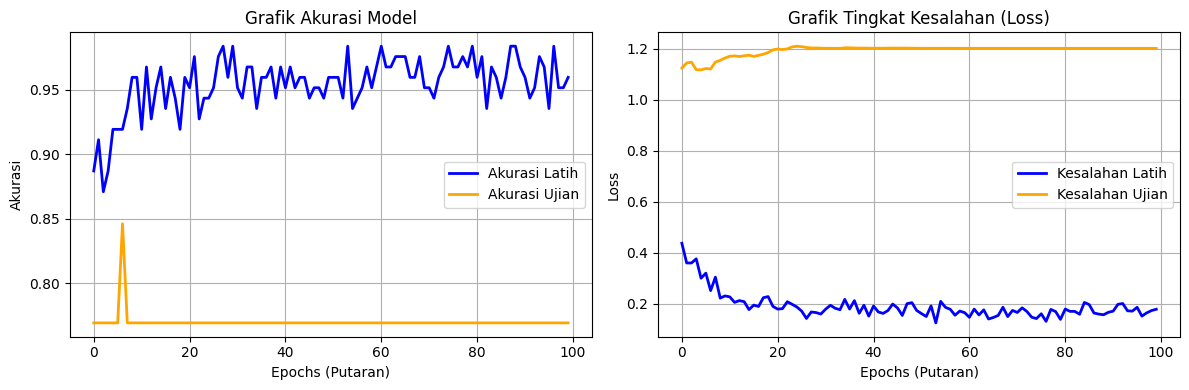

In [21]:

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Akurasi Latih', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Akurasi Ujian', color='orange', linewidth=2)
plt.title('Grafik Akurasi Model')
plt.xlabel('Epochs (Putaran)')
plt.ylabel('Akurasi')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Kesalahan Latih', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Kesalahan Ujian', color='orange', linewidth=2)
plt.title('Grafik Tingkat Kesalahan (Loss)')
plt.xlabel('Epochs (Putaran)')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [22]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

pred = np.argmax(
    model.predict(X_test),
    axis=1
)

print(
    f"Accuracy: {accuracy_score(y_test, pred):.4f}"
)

print(
    classification_report(
        y_test,
        pred,
        target_names=le.classes_
    )
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Accuracy: 0.8750
               precision    recall  f1-score   support

  Clutch-Shoe       1.00      1.00      1.00         3
Conecting-Rod       1.00      1.00      1.00         2
   Drive-Belt       0.75      1.00      0.86         3
       Piston       1.00      1.00      1.00         1
       Roller       0.75      1.00      0.86         3
       Slider       0.00      0.00      0.00         2
    Tensioner       1.00      1.00      1.00         2

     accuracy                           0.88        16
    macro avg       0.79      0.86      0.82        16
 weighted avg       0.78      0.88      0.82        16



In [ ]:
import joblib

joblib.dump(
    le,
    "label_encoder.pkl"
)